# Image Retrieval

## CLIP для поиска изображений, соответствующих описаний и для поиска изображений, подобных запрашиваемому.

In [ ]:
!pip install faiss-cpu transformers torch pillow numpy scikit-learn matplotlib

In [1]:
from transformers import CLIPTokenizerFast, CLIPProcessor, CLIPModel 
import torch

from PIL import Image
import cv2
import os
from tqdm import tqdm
import numpy as np

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import euclidean_distances
import matplotlib.pyplot as plt

import faiss
import os

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


Определение модели

In [ ]:
model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id).to(device)
model.eval()

tokenizer = CLIPTokenizerFast.from_pretrained(model_id)
processor = CLIPProcessor.from_pretrained(model_id)

## Создание векторной БД FAISS

Функции для получение векторных представлений из изображений и тектса

In [ ]:
def get_image_embedding(image: Image.Image) -> np.ndarray:
    """Возвращает L2-нормализованный эмбеддинг изображения (512-dim, float32)."""
    inputs = processor(images=image, return_tensors="pt")
    with torch.inference_mode():
        features = model.get_image_features(**inputs)
    
    if not isinstance(features, torch.Tensor):
        features = features.pooler_output
    # Нормализуем
    features = features / features.norm(dim=-1, keepdim=True)
    return features.squeeze().numpy().astype("float32")

def get_text_embedding(text: str) -> np.ndarray:
    """Возвращает L2-нормализованный эмбеддинг текста (512-dim, float32)."""
    inputs = processor(text=[text], return_tensors="pt", padding=True)
    with torch.inference_mode():
        features = model.get_text_features(**inputs)
    if not isinstance(features, torch.Tensor):
        features = features.pooler_output
    features = features / features.norm(dim=-1, keepdim=True)
    return features.squeeze().numpy().astype("float32")

In [ ]:
EMBEDDING_DIM = 512

index = faiss.IndexFlatIP(EMBEDDING_DIM)

path = 'data'

# Добавляем эмбеддинги (shape: N x 512, dtype: float32)
embeddings = np.stack([get_image_embedding(Image.open(os.path.join(path, img))) for img in os.listdir(path)])
index.add(embeddings)

print(f"Vectors in index: {index.ntotal}")

In [38]:
faiss.write_index(index, "clip_image_index.faiss")
print("Index saved.")

Index saved.


### Поиск по изображению

In [4]:
index = faiss.read_index("clip_image_index.faiss")

  #1: image_index=6033, cosine_similarity=0.9143
  #2: image_index=8807, cosine_similarity=0.9026
  #3: image_index=8242, cosine_similarity=0.9024
  #4: image_index=2024, cosine_similarity=0.8935
  #5: image_index=7339, cosine_similarity=0.8908


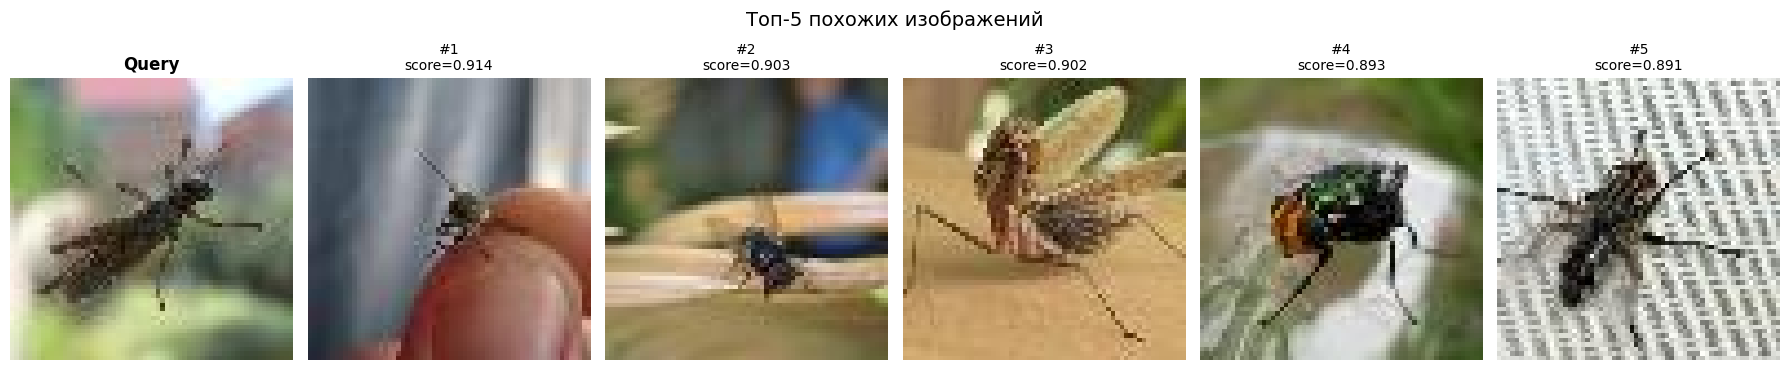

In [7]:
query_image = Image.open(r"assets\query_image.JPEG")
query_embedding = get_image_embedding(query_image)
query_vec = query_embedding.reshape(1, -1)

k = 5

distances, indices = index.search(query_vec, k)

image_files = os.listdir(path)

for rank, (dist, idx) in enumerate(zip(distances[0], indices[0])):
    print(f"  #{rank+1}: image_index={idx}, cosine_similarity={dist:.4f}")

fig, axs = plt.subplots(1, k + 1, figsize=(3 * (k + 1), 4))

axs[0].imshow(query_image)
axs[0].set_title("Query", fontsize=12, fontweight="bold")
axs[0].axis("off")

for rank, (dist, idx) in enumerate(zip(distances[0], indices[0])):
    img = Image.open(os.path.join(path, image_files[idx]))
    axs[rank + 1].imshow(img)
    axs[rank + 1].set_title(f"#{rank+1}\nscore={dist:.3f}", fontsize=10)
    axs[rank + 1].axis("off")

plt.suptitle(f"Топ-{k} похожих изображений", fontsize=14)
plt.tight_layout()
plt.show()

### Поиск по тексту

Запрос: 'car on a road'
  #1: image_index=3456, cosine_similarity=0.2642
  #2: image_index=6691, cosine_similarity=0.2548
  #3: image_index=2049, cosine_similarity=0.2546
  #4: image_index=8196, cosine_similarity=0.2511
  #5: image_index=8362, cosine_similarity=0.2481


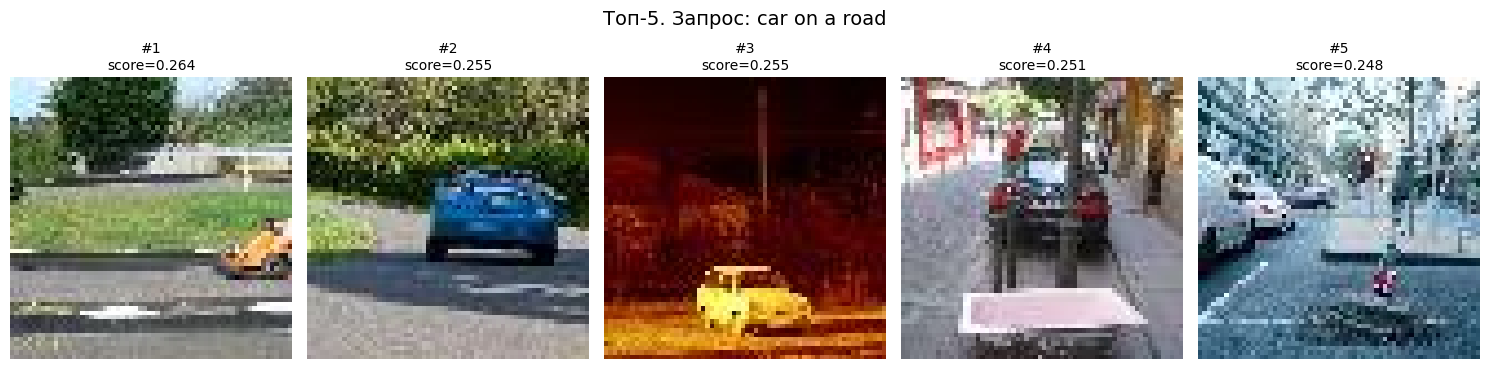

In [8]:
query_text = 'car on a road'
query_embedding = get_text_embedding(query_text)
query_vec = query_embedding.reshape(1,-1)

distances, indices = index.search(query_vec, k=5)

print(f"Запрос: '{query_text}'")
for rank, (dist, idx) in enumerate(zip(distances[0], indices[0])):
    print(f"  #{rank+1}: image_index={idx}, cosine_similarity={dist:.4f}")

fig, axs = plt.subplots(1, k, figsize=(3 * k, 4))

for rank, (dist, idx) in enumerate(zip(distances[0], indices[0])):
    img = Image.open(os.path.join(path, image_files[idx]))
    axs[rank].imshow(img)
    axs[rank].set_title(f"#{rank+1}\nscore={dist:.3f}", fontsize=10)
    axs[rank ].axis("off")

plt.suptitle(f"Топ-{k}. Запрос: {query_text}", fontsize=14)
plt.tight_layout()
plt.show()